In [3]:
import pandas as pd
import yfinance as yf
from pytickersymbols import PyTickerSymbols
import time


# Dictionary mapping symbols to company names
SYMBOL_NAMES = {
    "AAPL": "Apple Inc.",
    "MSFT": "Microsoft Corporation",
    "NVDA": "NVIDIA Corporation",
    "TSLA": "Tesla Inc.",
    "AMZ": "Amazon Inc.",
    "GOOGL": "Alphabet Inc.",
    "META": "Meta Platforms",
    "BRK.B": "Berkshire Hathaway",
    "JNJ": "Johnson & Johnson",
    "V": "Visa Inc.",
}


def get_company_name(symbol: str) -> str:
    """Get company name for symbol, fetch if not in cache."""
    if symbol in SYMBOL_NAMES:
        return SYMBOL_NAMES[symbol]
    try:
        info = yf.Ticker(symbol).info
        return info.get("longName", symbol)
    except:
        return symbol


def get_top_5_symbols(limit: int = 50, source: str = "SP500", delay: float = 0.5) -> list[str]:
    """Get top 5 tickers by daily percentage move with rate limiting."""
    stock_data = PyTickerSymbols()
    
    # Use SP500 by default (more reliable than full US list)
    if source == "SP500":
        symbol_list = list(stock_data.get_sp_500_nyc_yahoo_tickers())[:limit]
    else:
        symbol_list = [s["symbol"] for s in list(stock_data.get_stocks_by_country("US"))[:limit]]

    print(f"Fetching data for {len(symbol_list)} symbols (with {delay}s delay)...")
    
    performance = []
    failed_count = 0
    success_count = 0
    
    for i, sym in enumerate(symbol_list):
        try:
            print(f"[{i+1}/{len(symbol_list)}] Fetching {sym}...", end="", flush=True)
            hist = yf.Ticker(sym).history(period="2d", interval="1d")
            
            if hist.empty or "Close" not in hist.columns or len(hist) < 2:
                print(" (no data)")
                continue

            prev_close = hist["Close"].iloc[-2]
            last_close = hist["Close"].iloc[-1]
            
            if pd.isna(prev_close) or pd.isna(last_close) or prev_close == 0:
                print(" (NaN/zero)")
                continue

            pct = (last_close - prev_close) / prev_close * 100
            performance.append((sym, pct))
            success_count += 1
            print(f" ✓ {pct:+.2f}%")
            
        except Exception as e:
            failed_count += 1
            error_msg = str(e)[:40]
            print(f" ✗ {error_msg}")
        
        # Rate limit: add delay between requests
        time.sleep(delay)

    print(f"\n✓ Successfully fetched {success_count} symbols. ✗ {failed_count} failed.")
    
    if not performance:
        print("WARNING: No valid symbols found. Using fallback symbols.")
        # Fallback: hardcoded symbols if API fails
        fallback_symbols = ["AAPL", "MSFT", "NVDA", "TSLA", "AMZ"]
        return fallback_symbols
    
    performance.sort(key=lambda x: x[1], reverse=True)
    top5 = [sym for sym, _ in performance[:5]]
    print(f"\nTop 5:")
    for sym, pct in performance[:5]:
        company_name = get_company_name(sym)
        print(f"  {sym} - {company_name}: {pct:+.2f}%")
    return top5


# Try SP500 first (more reliable), reduce limit to 50 to speed up fetching
# top5_symbols = get_top_5_symbols(limit=20, source="SP500", delay=0.7)
top5_symbols = get_top_5_symbols(limit=50, source="SP500", delay=0.7)
print(f"\nFinal Top 5: {top5_symbols}")

# Fetch OHLC data
ohlc_data = {}
for sym in top5_symbols:
    try:
        ohlc_data[sym] = yf.Ticker(sym).history(period="7d", interval="1d")[["Open", "High", "Low", "Close"]]
        print(f"✓ Fetched OHLC for {sym}")
    except Exception as e:
        print(f"✗ Failed OHLC for {sym}: {e}")

# Display with company names and formatted prices
for sym, df in ohlc_data.items():
    company_name = get_company_name(sym)
    print(f"\n{sym} - {company_name} (last 7 days):")
    # Format prices with $
    df_display = df.copy()
    for col in ["Open", "High", "Low", "Close"]:
        df_display[col] = "$" + df_display[col].apply(lambda x: f"{x:.2f}")
    print(df_display)

Fetching data for 50 symbols (with 0.7s delay)...
[1/50] Fetching MMM... ✓ -0.36%
[2/50] Fetching ABT... ✓ -2.03%
[3/50] Fetching ACN... ✓ +2.57%
[4/50] Fetching ADBE... ✓ +2.68%
[5/50] Fetching ALB... ✓ -1.24%
[6/50] Fetching ALGN... ✓ -0.07%
[7/50] Fetching ALLE... ✓ -1.11%
[8/50] Fetching GOOGL... ✓ -0.31%
[9/50] Fetching GOOG... ✓ -0.23%
[10/50] Fetching GOOGL... ✓ -0.31%
[11/50] Fetching GOOG... ✓ -0.23%
[12/50] Fetching AMZN... ✓ +0.81%
[13/50] Fetching AMCR... ✓ -1.32%
[14/50] Fetching AMCCF...

$AMCCF: possibly delisted; no price data found  (period=2d)


 (no data)
[15/50] Fetching AMGN... ✓ +0.07%
[16/50] Fetching AON... ✓ +3.32%
[17/50] Fetching APA... ✓ -1.46%
[18/50] Fetching AAPL... ✓ -0.87%
[19/50] Fetching APTV... ✓ -0.60%
[20/50] Fetching AJG... ✓ +4.27%
[21/50] Fetching T... ✓ -1.10%
[22/50] Fetching BKR... ✓ -4.02%
[23/50] Fetching BLL...

$BLL: possibly delisted; no price data found  (period=2d) (Yahoo error = "No data found, symbol may be delisted")


 (no data)
[24/50] Fetching BALY... ✓ -7.50%
[25/50] Fetching BALL... ✓ -2.09%
[26/50] Fetching BAC... ✓ +0.55%
[27/50] Fetching BOAPL...

$BOAPL: possibly delisted; no price data found  (period=2d) (Yahoo error = "No data found, symbol may be delisted")


 (no data)
[28/50] Fetching BAX... ✓ -1.06%
[29/50] Fetching BRK-B... ✓ +1.32%
[30/50] Fetching BLK... ✓ +0.02%
[31/50] Fetching BA... ✓ -0.69%
[32/50] Fetching BSX... ✓ -9.02%
[33/50] Fetching BRO... ✓ +2.89%
[34/50] Fetching CPT... ✓ +0.91%
[35/50] Fetching CCL... ✓ -0.95%
[36/50] Fetching CUK... ✓ -0.83%
[37/50] Fetching CUKPF... (no data)
[38/50] Fetching CAT... ✓ -4.02%
[39/50] Fetching CDW... ✓ +0.29%
[40/50] Fetching CNC... ✓ -0.63%
[41/50] Fetching SCHW... ✓ +0.76%
[42/50] Fetching CVX... ✓ -0.21%
[43/50] Fetching CB... ✓ +1.96%
[44/50] Fetching C... ✓ -0.10%
[45/50] Fetching KO... ✓ +0.74%
[46/50] Fetching CTSH... ✓ +2.23%
[47/50] Fetching COP... ✓ -0.68%
[48/50] Fetching GLW... ✓ -6.04%
[49/50] Fetching CRH... ✓ +0.17%
[50/50] Fetching CRHCF...

$CRHCF: possibly delisted; no price data found  (period=2d) (Yahoo error = "No data found, symbol may be delisted")


 (no data)

✓ Successfully fetched 45 symbols. ✗ 0 failed.

Top 5:
  AJG - Arthur J. Gallagher & Co.: +4.27%
  AON - Aon plc: +3.32%
  BRO - Brown & Brown, Inc.: +2.89%
  ADBE - Adobe Inc.: +2.68%
  ACN - Accenture plc: +2.57%

Final Top 5: ['AJG', 'AON', 'BRO', 'ADBE', 'ACN']
✓ Fetched OHLC for AJG
✓ Fetched OHLC for AON
✓ Fetched OHLC for BRO
✓ Fetched OHLC for ADBE
✓ Fetched OHLC for ACN

AJG - Arthur J. Gallagher & Co. (last 7 days):
                              Open     High      Low    Close
Date                                                         
2026-03-20 00:00:00-04:00  $210.39  $215.86  $210.21  $214.82
2026-03-23 00:00:00-04:00  $217.37  $218.54  $215.08  $216.74
2026-03-24 00:00:00-04:00  $218.27  $218.34  $214.89  $216.28
2026-03-25 00:00:00-04:00  $217.29  $218.83  $211.71  $213.56
2026-03-26 00:00:00-04:00  $214.03  $217.21  $209.60  $210.27
2026-03-27 00:00:00-04:00  $210.07  $213.17  $205.90  $207.10
2026-03-30 00:00:00-04:00  $208.01  $217.25  $206.50  $215.95


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


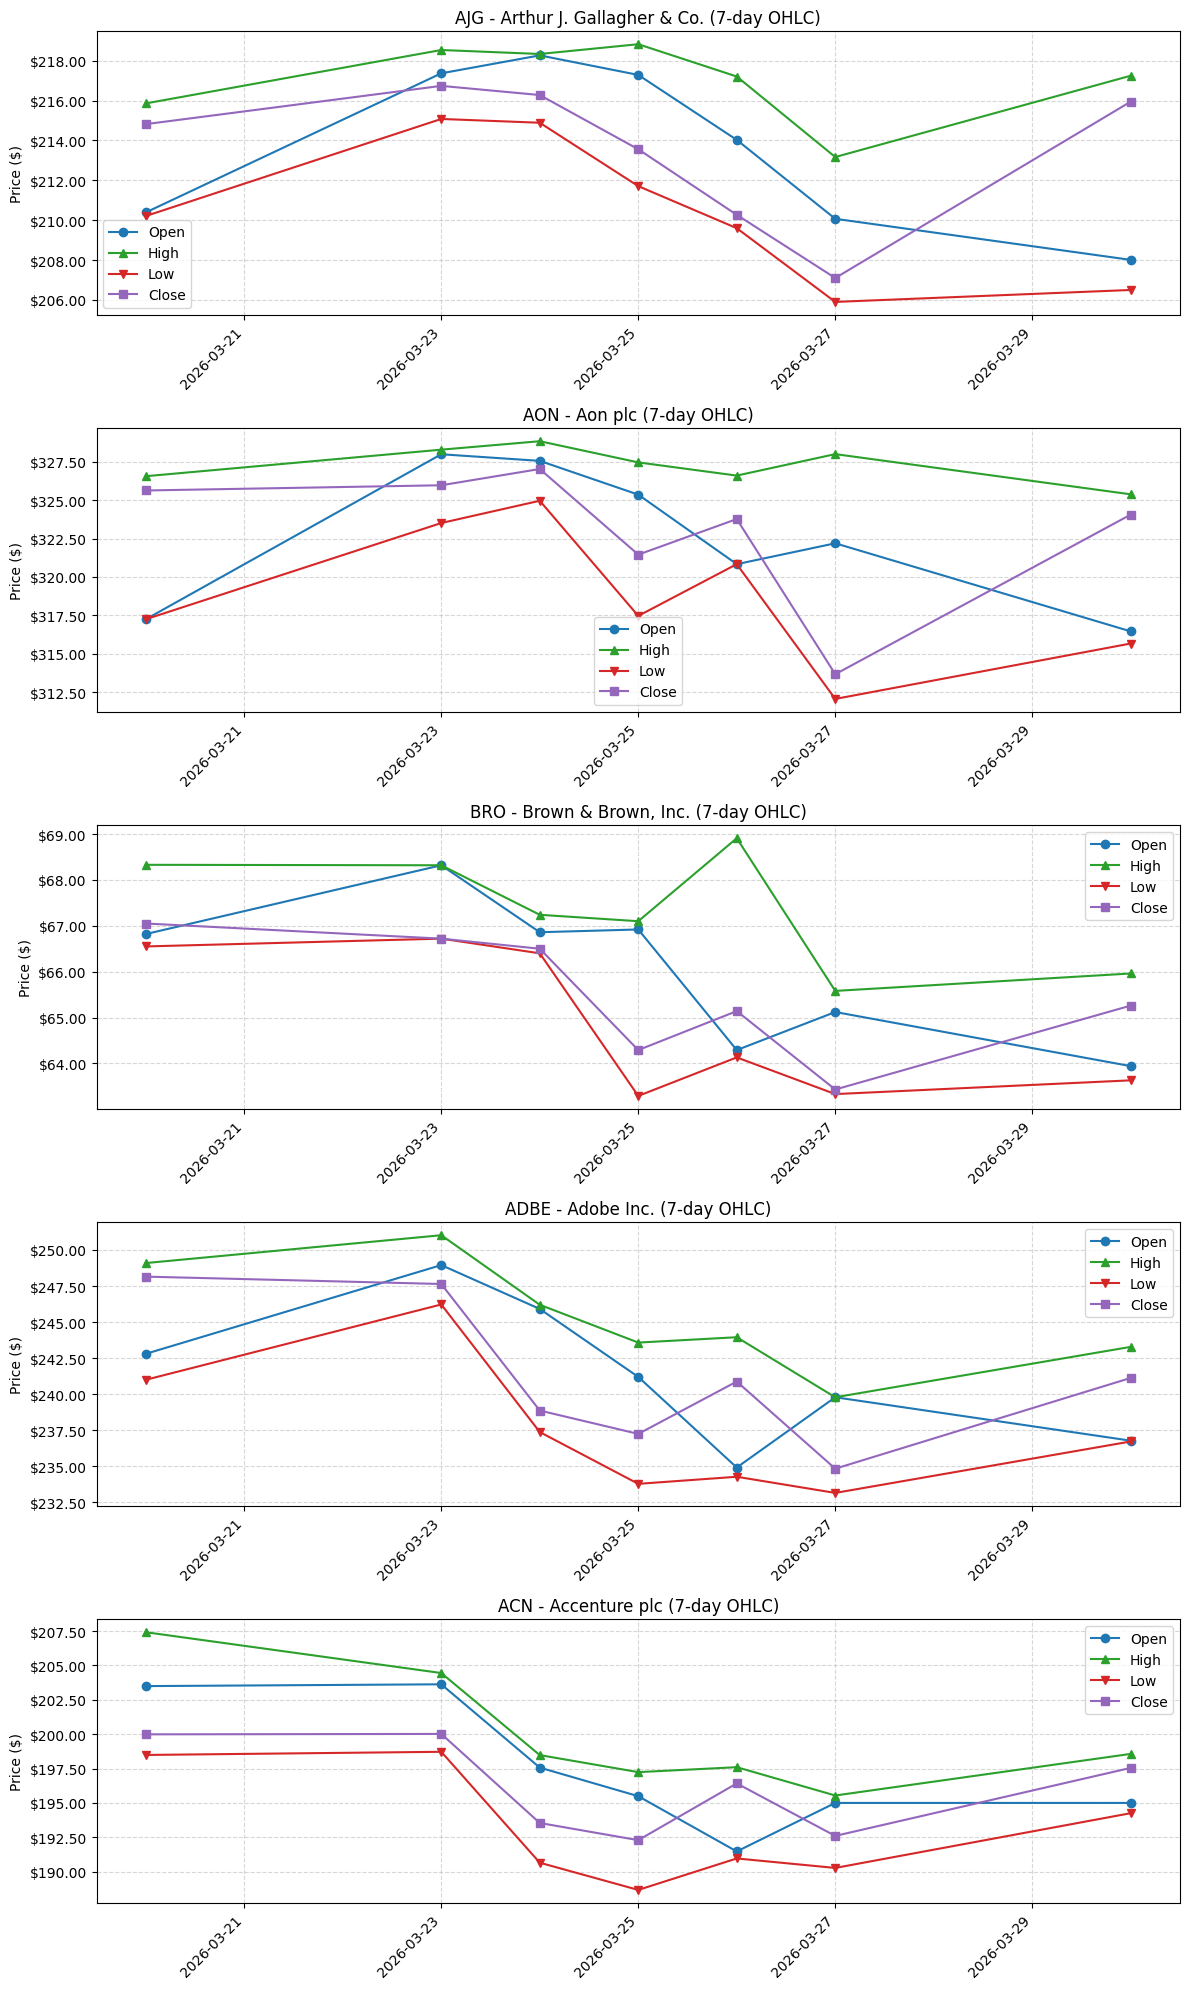

In [4]:
%pip install matplotlib

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def dollar_formatter(x, pos):
    """Format y-axis values as currency."""
    return f"${x:.2f}"

n = len(ohlc_data)
fig, axs = plt.subplots(n, 1, figsize=(12, 4 * max(1, n)), sharex=False)
if n == 1:
    axs = [axs]

for ax, (sym, df) in zip(axs, ohlc_data.items()):
    company_name = get_company_name(sym)
    ax.plot(df.index, df["Open"], marker="o", label="Open", color="tab:blue")
    ax.plot(df.index, df["High"], marker="^", label="High", color="tab:green")
    ax.plot(df.index, df["Low"], marker="v", label="Low", color="tab:red")
    ax.plot(df.index, df["Close"], marker="s", label="Close", color="tab:purple")
    ax.set_title(f"{sym} - {company_name} (7-day OHLC)")
    ax.set_ylabel("Price ($)")
    ax.yaxis.set_major_formatter(FuncFormatter(dollar_formatter))
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.legend()
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha("right")

plt.tight_layout()
plt.show()